In [1]:
import pandas as pd
import numpy as np
import matplotlib.gridspec
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from adjustText import adjust_text

/ihome/djishnu/alo90/.local/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/ihome/djishnu/alo90/.local/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [8]:
#Load in all genes from the analysis
taiji_genes = pd.read_csv('../../Data/GRN_genes_all_sets_ALLGENES.csv')
taiji_genes_set = set(taiji_genes['Genes'])

In [14]:
#Load in the LogFC RNA seq:
#Load in Taiji results from all ranks. 
atac_genes = pd.read_csv('/ix/djishnu/Alisa/Tfh/testing_for_github/Data/From_Taiji/output_ATAC/GeneRanks.tsv', sep='\t').rename(columns={'Unnamed: 0':"Genes", "Early_Pre_TFH":'Early Extra-GC', 'Late_Pre_TFH': 'Late Extra-GC'}).set_index("Genes")
H3K4me1_genes = pd.read_csv('/ix/djishnu/Alisa/Tfh/testing_for_github/Data/From_Taiji/output_CUTNRUN_H3K4me1/GeneRanks.tsv', sep='\t').rename(columns={'Unnamed: 0':"Genes", 'CXCR5pos_PD1neg': 'Early Extra-GC', 'CXCR5pos_PD1int': 'Late Extra-GC', 'CXCR5hi_PD1hi': 'GC'}).set_index("Genes")
H3K4me3_genes = pd.read_csv('/ix/djishnu/Alisa/Tfh/testing_for_github/Data/From_Taiji/output_CUTNRUN_H3K4me3/GeneRanks.tsv', sep='\t').rename(columns={'Unnamed: 0':"Genes", 'CXCR5pos_PD1neg': 'Early Extra-GC', 'CXCR5pos_PD1int': 'Late Extra-GC', 'CXCR5hi_PD1hi': 'GC'}).set_index("Genes")
H3K27Ac_genes = pd.read_csv('/ix/djishnu/Alisa/Tfh/testing_for_github/Data/From_Taiji/output_CUTNRUN_H3K27Ac/GeneRanks.tsv', sep='\t').rename(columns={'Unnamed: 0':"Genes", 'CXCR5pos_PD1neg': 'Early Extra-GC', 'CXCR5pos_PD1int': 'Late Extra-GC', 'CXCR5hi_PD1hi': 'GC'}).set_index("Genes")

# Concatenate and compute mean across available values
average_df = pd.concat([atac_genes, H3K4me1_genes, H3K4me3_genes, H3K27Ac_genes]).groupby(level=0).mean()
average_df = average_df.reset_index()
average_df = average_df[["Genes", "Naive", "Early Extra-GC", "Late Extra-GC", "GC"]]

logfc_df = pd.read_csv('../../Data/bulk_RNA/rna_earlyvsGC_Thresh_log2FC.csv')
logfc_df = logfc_df.drop(columns={'Unnamed: 0'})
merged_df = average_df.merge(logfc_df, on='Genes', how='left')


In [15]:
#Calculate Taiji Rank Importance
merged_df['Importance'] = np.log2(merged_df['GC'] / merged_df['Early Extra-GC'])
merged_df = merged_df.set_index("Genes")

{'YY1', 'ATF4', 'KLF10', 'STAT6', 'BCL6', 'HIF1A', 'ZNF333', 'GATA3', 'JUNB', 'AHR', 'RORA', 'SP3', 'FOXO3', 'ZNF274', 'DNMT1', 'RELA', 'SATB1', 'FOXK1', 'E2F4', 'TGIF1', 'HSF1', 'STAT3', 'IRF7', 'SREBF2', 'ZNF891', 'MZF1', 'ELF1', 'SP2', 'IKZF1', 'ZBTB17', 'ZNF776', 'NFYA', 'ZNF467', 'ELK1', 'JUN', 'KLF13', 'IRF2', 'ZNF548', 'ZSCAN30', 'FOSL2', 'ATF3', 'ZNF143', 'ZNF148', 'IRF8', 'NRF1', 'ZNF441', 'BATF', 'FOXO1', 'MAF', 'NFYC', 'SPIB', 'ELK4', 'ZNF770', 'GABPA', 'ZSCAN22', 'REL', 'POU2F2', 'PRDM1', 'ZNF267', 'MEF2D', 'ZNF100', 'FOS', 'SP4', 'STAT2', 'KLF7', 'ELF4', 'ZNF460', 'ATF6B', 'TCF7', 'IRF9', 'POU2F1', 'PBX3', 'ZBTB33', 'NFATC2', 'THAP11', 'FOXJ3', 'SOX4', 'NR4A2', 'ZNF22', 'CTCF', 'KLF12', 'KLF2', 'FOXN3', 'REST', 'NR2F6', 'ZNF121', 'NR3C1', 'ZNF766', 'ZNF783', 'KLF4', 'GTF2I', 'ZNF331', 'FOSB', 'ZFP82', 'RFX5', 'ELF2', 'IRF4', 'VEZF1', 'ZNF543', 'FLI1', 'NR4A1', 'RUNX1', 'RREB1', 'JUND', 'CREB1', 'GTF2B', 'EGR2', 'KLF3', 'ELK3', 'ZNF557', 'NFATC1', 'MEF2C', 'BCL11A', 'ZNF354

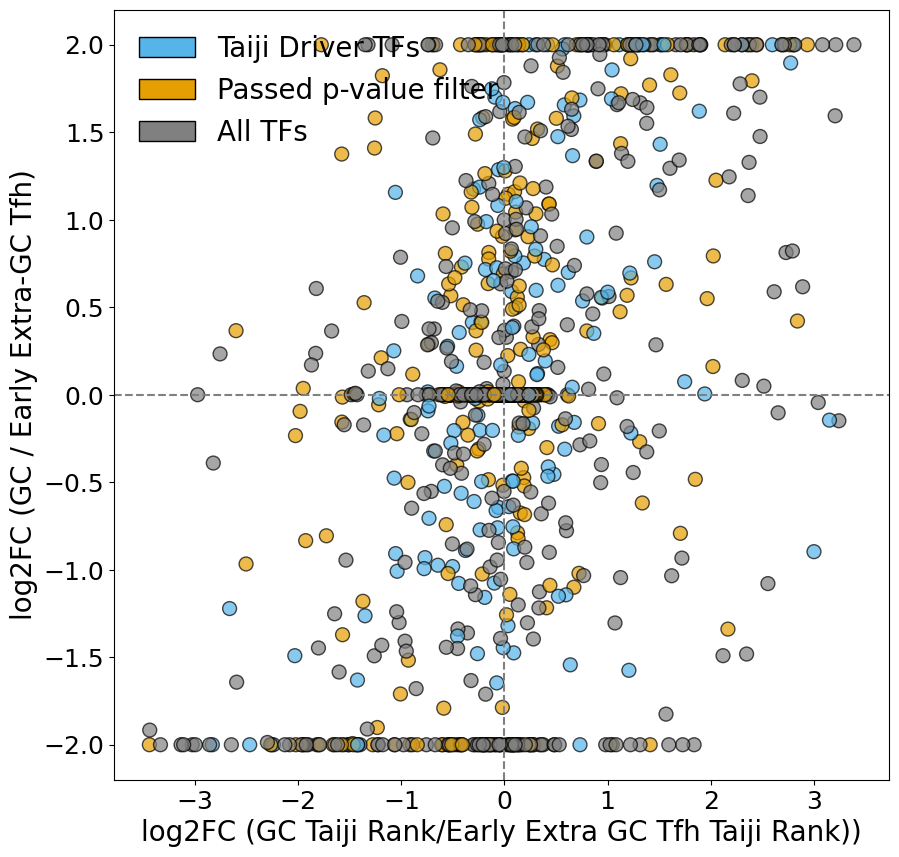

In [31]:
# Load the gene list for highlighting (e.g., 'target genes')

# Load the p-value filtered list (e.g., significant genes only)
pval_filtered_df = pd.read_csv("../../Data/GRN_genes_all_sets_152.csv")  # One column: 'Gene'
significant_genes = set(pval_filtered_df['Genes'])
print(significant_genes)


# Categorize genes
def assign_color(gene):
    if gene in significant_genes:
        return '#56B4E9'            # In the highlight list
           # Failed p-value filter
    if gene in taiji_genes_set:
        return "#E69F00"
    else:
        return 'grey'       # Other

# Assume merged_df index is gene names
merged_df['Color'] = merged_df.index.map(assign_color)

# Plot
fig = plt.figure(figsize=(10, 10))

sc = plt.scatter(
    merged_df['Importance'],
    merged_df['LogChange_Thresh'],
    c=merged_df['Color'],
    edgecolor='k',
    alpha=0.7,
    s=100
)

plt.axhline(0, linestyle='--', color='gray')
plt.axvline(0, linestyle='--', color='gray')
plt.ylabel('log2FC (GC / Early Extra-GC Tfh)', fontsize=20)
plt.xlabel('log2FC (GC Taiji Rank/Early Extra GC Tfh Taiji Rank))', fontsize=20)

plt.tick_params(axis='both', labelsize=18)

# Optional legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#56B4E9', edgecolor='k', label='Taiji Driver TFs'),
    Patch(facecolor='#E69F00', edgecolor='k', label='Passed p-value filter'),
    Patch(facecolor='gray', edgecolor='k', label='All TFs')
]
plt.legend(handles=legend_elements, fontsize=20, frameon=False)

In [39]:
color_meaning = []
for i in range(0, len(merged_df)):
    color = merged_df['Color'][i]
    if color == 'grey':
        color_meaning.append('All TFs')
    if color == '#E69F00':
        color_meaning.append('Passed p-value filter')
    if color == '#56B4E9':
        color_meaning.append('Taiji Driver TFs')
    

/scratch/slurm-9443113/ipykernel_3127707/1776769549.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = merged_df['Color'][i]


In [41]:
merged_df['Label']= color_meaning

In [42]:
merged_df.to_csv("GC_vs_Early_ImportancePlot_SourceData.csv")

In [13]:
# Save as PNG
fig.savefig("GC_vs_Early_ImportancePlot_allTFs.png", dpi=300, bbox_inches='tight')

# Save as PDF
fig.savefig("GC_vs_Early_ImportancePlot_allTFs.pdf", bbox_inches='tight')
